# N12 — Arquiteturas Multiagentes

* Professor: Julio Cesar dos Reis <a href="mailto:dosreis@unicamp.br">(dosreis@unicamp.br)</a>
* Monitor: Renan dos Santos Morais <a href="mailto:r299211@dac.unicamp.br">(r299211@dac.unicamp.br)</a>


## 0.1 Pré-requisitos

Para acompanhar este notebook, é esperado que você já tenha:

- usado `create_agent` para montar um agente com ferramentas
- noções de saída estruturada com `pydantic` para construir roteadores por LLM
- noções de `StateGraph`, nós e arestas condicionais


## 0.2 Objetivos da aula

Ao final deste notebook, você deverá saber:

1. Criar um agente especialista único com `create_agent`.
2. Combinar dois agentes com um roteamento simples, feito em Python puro.
3. Explicar por que roteamento manual por palavra-chave não escala.
4. Construir um **orquestrador**: um agente que decide, via LLM, qual agente especialista chamar (padrão *subagents as tools*).
5. Reimplementar a mesma equipe de agentes como uma **arquitetura de grafo** explícita, usando `StateGraph` e `Command`.
6. Comparar as duas arquiteturas e saber quando cada uma é mais apropriada.


## 0.3 Mapa do notebook

Neste notebook, vamos construir progressivamente:

1. Por que dividir um assistente em vários agentes.
2. Um agente especialista único, com `create_agent`.
3. Dois agentes, com roteamento trivial (Python puro, sem LLM decidindo).
4. Por que o roteamento manual não escala.
5. Três agentes com um **orquestrador** (padrão *subagents as tools*).
6. A mesma equipe como **arquitetura de grafo**, com `StateGraph` e `Command`.
7. Comparando as duas arquiteturas.


## 0.4 Contexto usado nos exemplos

Seguimos o mesmo cenário dos notebooks anteriores — o curso de LangGraph — mas agora ele é grande o suficiente para justificar mais de um agente. Em vez de um único assistente tentando responder tudo, vamos montar uma pequena equipe:

| Agente | Responsabilidade | Ferramentas |
|---|---|---|
| `agente_tutor` | Dúvidas técnicas sobre o conteúdo dos módulos | `consultar_modulo` |
| `agente_secretaria` | Questões administrativas: prazos, matrícula, certificado | `consultar_prazo`, `emitir_declaracao` |
| `agente_pesquisa` | Definições de conceitos gerais de LangGraph | `buscar_conceito` |

---

## 0.5 Preparação do ambiente

Vamos usar os mesmos pacotes dos notebooks anteriores — nada novo em termos de instalação.

In [1]:
# Descomente se estiver em um ambiente sem as dependências instaladas.
%pip install -U langgraph langchain langchain-ollama pydantic


   ---------------------------------------- 0.0/248.9 kB ? eta -:--:--
   --------- ------------------------------ 61.4/248.9 kB 1.7 MB/s eta 0:00:01
   ---------------------------------------- 248.9/248.9 kB 3.1 MB/s eta 0:00:00
   ---------------------------------------- 0.0/147.0 kB ? eta -:--:--
   ---------------------------------------- 147.0/147.0 kB 8.5 MB/s eta 0:00:00
   ---------------------------------------- 0.0/565.1 kB ? eta -:--:--
   --------------------------------------- 565.1/565.1 kB 17.9 MB/s eta 0:00:00
  Attempting uninstall: langchain-core
    Found existing installation: langchain-core 1.5.3
    Uninstalling langchain-core-1.5.3:
      Successfully uninstalled langchain-core-1.5.3
  Attempting uninstall: langgraph
    Found existing installation: langgraph 1.2.10
    Uninstalling langgraph-1.2.10:
      Successfully uninstalled langgraph-1.2.10
  Attempting uninstall: langchain
    Found existing installation: langchain 1.3.14
    Uninstalling langchain-1.3.14


[notice] A new release of pip is available: 24.0 -> 26.2.1
[notice] To update, run: C:\Users\DELL\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


Imports usados ao longo da aula.

In [2]:
from typing import Annotated, Literal, TypedDict

from langchain.agents import create_agent
from langchain.chat_models import init_chat_model
from langchain_core.messages import BaseMessage, SystemMessage
from langchain_core.tools import tool
from pydantic import BaseModel, Field

from langgraph.graph import StateGraph, START, END
from langgraph.graph.message import add_messages
from langgraph.types import Command


Funções auxiliares de exibição — as mesmas dos notebooks anteriores.

In [3]:
from langgraph.graph.state import CompiledStateGraph
from IPython.display import Image, display, Markdown


def display_graph(graph: CompiledStateGraph) -> None:
    display(Image(graph.get_graph().draw_mermaid_png()))


def print_last_message(result: dict) -> None:
    display(Markdown(result["messages"][-1].content))


Inicializamos o modelo, seguindo o mesmo processo dos notebooks anteriores.

In [5]:
# Reaproveite aqui a mesma configuração de LLM usada nos notebooks anteriores.
#llm = init_chat_model("ollama:llama3.2:3b", temperature=0)

import os

from dotenv import load_dotenv

load_dotenv()
print("Chave OPENAI_API_KEY configurada com sucesso." if "OPENAI_API_KEY" in os.environ else "Chave não encontrada.")

llm = init_chat_model("openai:gpt-4o-mini", temperature=0)


Chave OPENAI_API_KEY configurada com sucesso.


Por fim, os dados e ferramentas que os agentes vão usar — trivial de propósito, o foco desta aula é a arquitetura, não as ferramentas em si.

In [6]:
MODULOS_CURSO = {
    "A4": {"tema": "Ferramentas e create_agent", "duracao_horas": 6},
    "A5": {"tema": "Memória em LangGraph", "duracao_horas": 5},
    "A6": {"tema": "Memória Reflexiva", "duracao_horas": 4},
    "A7": {"tema": "Arquiteturas Multiagente", "duracao_horas": 6},
}

PRAZOS_CURSO = {
    "matricula": "até 20/08/2026",
    "trancamento": "até 30/09/2026",
    "certificado": "emitido em até 10 dias úteis após a conclusão do último módulo",
}

BASE_CONHECIMENTO = {
    "reducer": "Reducers controlam como o novo valor de um campo do estado se combina com o valor anterior a cada atualização.",
    "runnableconfig": "RunnableConfig carrega metadados de execução, como thread_id, acessíveis via config['configurable'].",
    "checkpointer": "Um checkpointer salva o estado inteiro do grafo a cada passo, associado a um thread_id — memória de curto prazo.",
    "store": "Um store guarda informação organizada em namespaces, acessível de qualquer thread — memória de longo prazo.",
}


def consultar_modulo(codigo_modulo: str) -> dict:
    """Retorna o tema e a carga horária de um módulo do curso, dado seu código (ex.: A6)."""
    return MODULOS_CURSO.get(codigo_modulo, {"erro": "módulo não encontrado"})


def consultar_prazo(tipo: str) -> str:
    """Consulta prazos administrativos do curso. tipo pode ser: matricula, trancamento ou certificado."""
    return PRAZOS_CURSO.get(tipo, "Prazo não encontrado. Fale diretamente com a secretaria.")


def emitir_declaracao(aluno: str, modulo_atual: str) -> str:
    """Emite uma declaração simples de matrícula ativa para o aluno."""
    return f"Declaração emitida: {aluno} está matriculado(a) e cursando o módulo {modulo_atual}."


def buscar_conceito(termo: str) -> str:
    """Busca a definição de um conceito técnico de LangGraph na base de conhecimento do curso."""
    termo_normalizado = termo.lower().strip()
    for chave, definicao in BASE_CONHECIMENTO.items():
        if chave in termo_normalizado or termo_normalizado in chave:
            return definicao
    return "Conceito não encontrado na base de conhecimento do curso."


---

# 1. Por que dividir um assistente em vários agentes

Até o momento, construímos um único agente que acumulava responsabilidades: responder dúvidas, usar ferramentas, lembrar de conversas, refletir sobre erros. Isso funciona até certo ponto, mas cresce mal:

- o **prompt de sistema** vira uma lista cada vez maior de instruções, muitas delas conflitantes entre si;
- o **conjunto de ferramentas** cresce, e o modelo passa a errar mais na hora de escolher qual usar;
- fica difícil **testar e ajustar** uma responsabilidade sem afetar as outras.

A alternativa é dividir o trabalho: em vez de um agente generalista, uma equipe de agentes **especialistas**, cada um com um escopo pequeno e um prompt focado. 

O desafio que resta é **como coordenar** essa equipe — 

Esse é o foco desse notebook, começando do caso mais simples até o mais explícito.


---

# 2. Um agente especialista com `create_agent`

`create_agent` monta, com poucos parâmetros, um grafo completo de agente — um nó que chama o modelo, um nó que executa ferramentas, e o ciclo entre eles até não haver mais `tool_calls`.

Vamos criar o primeiro especialista: o `agente_tutor`, que só sabe responder sobre o conteúdo dos módulos.

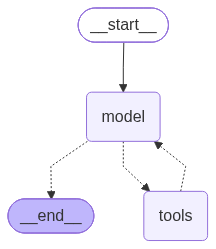

In [7]:
agente_tutor = create_agent(
    model=llm,
    tools=[consultar_modulo],
    system_prompt=(
        "Você é o tutor técnico do curso de LangGraph. "
        "Responda apenas dúvidas sobre o conteúdo e a carga horária dos módulos."
    ),
)

display_graph(agente_tutor)


In [8]:
resultado = agente_tutor.invoke(
    {"messages": [{"role": "user", "content": "Quantas horas tem o módulo A6 e sobre o que ele fala?"}]}
)
print_last_message(resultado)


O módulo A6 tem uma carga horária de 4 horas e aborda o tema "Memória Reflexiva".

## Discussão

Nada de novo até aqui. 

O ponto de partida de qualquer arquitetura multiagente é isto: **cada agente, individualmente, é só um `create_agent` com um escopo restrito.** 

A complexidade das próximas seções está inteiramente em como esses agentes se conectam, não em como cada um funciona sozinho.


---

# 3. Dois agentes, com roteamento trivial

Vamos criar um segundo especialista, `agente_secretaria`, para questões administrativas. Com só dois agentes, a forma mais simples de decidir quem responde é um `if` em Python — nenhum LLM precisa estar envolvido nessa decisão.

In [9]:
agente_secretaria = create_agent(
    model=llm,
    tools=[consultar_prazo, emitir_declaracao],
    system_prompt=(
        "Você é a secretaria do curso de LangGraph. "
        "Responda apenas dúvidas administrativas: prazos, matrícula, certificado."
    ),
)


In [11]:
def rotear_pergunta(pergunta: str):
    """Roteamento trivial: decide o agente só olhando palavras-chave na pergunta."""
    texto = pergunta.lower()
    palavras_administrativas = ["prazo", "matrícula", "matricula", "declaração", "declaracao", "certificado"]
    if any(palavra in texto for palavra in palavras_administrativas):
        return agente_secretaria
    return agente_tutor


def perguntar(pergunta: str) -> str:
    agente = rotear_pergunta(pergunta)
    resultado = agente.invoke({"messages": [{"role": "user", "content": pergunta}]})
    return resultado["messages"][-1].content


print(perguntar("Quantas horas tem o módulo A6?"))
print()
print(perguntar("Qual é o prazo de matrícula?"))


O módulo A6, que aborda o tema "Memória Reflexiva", tem uma carga horária de 4 horas.

O prazo de matrícula é até 20/08/2026.


## Discussão

Funciona, e é o mais simples possível: nenhum LLM decide quem responde, só uma lista de palavras-chave. 

Para dois agentes com escopos bem distintos, isso é suficiente — não vale a pena introduzir complexidade adicional cedo demais.

O problema aparece quando o número de agentes cresce, ou quando os escopos deixam de ser tão claramente separáveis por vocabulário. É isso que a próxima seção mostra.


---

# 4. Por que o roteamento manual não escala

Vamos adicionar um terceiro especialista, `agente_pesquisa`, que responde definições de conceitos gerais de LangGraph — e testar o `rotear_pergunta` de novo.

In [12]:
agente_pesquisa = create_agent(
    model=llm,
    tools=[buscar_conceito],
    system_prompt=(
        "Você é o agente de pesquisa conceitual do curso de LangGraph. "
        "Responda definições de conceitos técnicos gerais, sem falar de módulos específicos."
    ),
)


In [13]:
pergunta_ambigua = "Meu certificado vai citar o que é um checkpointer?"

print(perguntar(pergunta_ambigua))


Não tenho informações sobre o conteúdo específico do seu certificado. O certificado geralmente atesta a conclusão do curso e pode incluir informações sobre as disciplinas ou módulos cursados, mas não costuma detalhar conceitos específicos como "checkpointer". Para mais detalhes, recomendo consultar a coordenação do curso.


## O que aconteceu?

A pergunta contém `"certificado"` (que deveria ir para a secretaria) **e** pergunta sobre um conceito técnico (`checkpointer`, que deveria ir para a pesquisa). O `rotear_pergunta` nem sabe que `agente_pesquisa` existe — ele nunca foi conectado ao router. E mesmo se conectássemos, a lógica de palavras-chave já não seria suficiente: essa pergunta não pertence claramente a nenhum dos dois agentes.

Isso não é um problema de implementação malfeita — é um limite estrutural do roteamento por palavra-chave:

- ele não entende **intenção**, só vocabulário;
- cada agente novo multiplica as chances de colisão entre palavras-chave;
- perguntas legitimamente ambíguas (como a de cima) não têm uma resposta "certa" no `if/else`.

A solução é trocar a decisão de "qual agente chamar" de uma regra fixa em Python para um **LLM que decide** — um orquestrador.


---

# 5. Três agentes com um orquestrador

A forma mais direta de construir um orquestrador é o padrão **subagents as tools**: cada agente especialista vira uma *tool* que um agente orquestrador pode chamar. 

O orquestrador é, ele mesmo, só mais um `create_agent` — a diferença é que as ferramentas dele não fazem cálculo ou consulta a um dicionário, elas **invocam outro agente**.

```text
                     ┌──────────────┐
   pergunta  ──────▶ │ orquestrador │
                     └──────┬───────┘
                            │ decide qual tool chamar
              ┌─────────────┼─────────────┐
              ▼             ▼             ▼
     falar_com_tutor  falar_com_secretaria  falar_com_pesquisa
              │             │             │
              ▼             ▼             ▼
        agente_tutor  agente_secretaria  agente_pesquisa
```

## 5.1 Empacotando cada agente como uma *tool*

In [15]:
@tool
def falar_com_tutor(pergunta: str) -> str:
    """Encaminha uma dúvida sobre o CONTEÚDO TÉCNICO de um módulo do curso para o agente tutor."""
    resultado = agente_tutor.invoke({"messages": [{"role": "user", "content": pergunta}]})
    return resultado["messages"][-1].content


@tool
def falar_com_secretaria(pergunta: str) -> str:
    """Encaminha uma dúvida ADMINISTRATIVA (prazo, matrícula, certificado) para a secretaria."""
    resultado = agente_secretaria.invoke({"messages": [{"role": "user", "content": pergunta}]})
    return resultado["messages"][-1].content


@tool
def falar_com_pesquisa(pergunta: str) -> str:
    """Encaminha uma pergunta sobre DEFINIÇÃO DE CONCEITO GERAL de LangGraph para o agente de pesquisa."""
    resultado = agente_pesquisa.invoke({"messages": [{"role": "user", "content": pergunta}]})
    return resultado["messages"][-1].content


## 5.2 O orquestrador

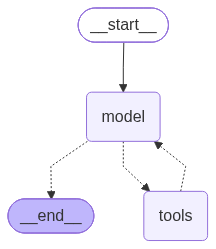

In [16]:
orquestrador = create_agent(
    model=llm,
    tools=[falar_com_tutor, falar_com_secretaria, falar_com_pesquisa],
    system_prompt=(
        "Você coordena um assistente do curso de LangGraph com três especialistas: "
        "tutor (conteúdo dos módulos), secretaria (administrativo) e pesquisa (conceitos gerais). "
        "Encaminhe cada pergunta ao(s) especialista(s) certo(s) e componha a resposta final para o aluno. "
        "Se a pergunta tocar mais de um assunto, consulte mais de um especialista antes de responder."
    ),
)

display_graph(orquestrador)


Testamos com a mesma pergunta ambígua da seção anterior.

In [17]:
resultado = orquestrador.invoke(
    {"messages": [{"role": "user", "content": pergunta_ambigua}]}
)
print_last_message(resultado)


O termo "checkpointer" refere-se a um componente que salva o estado inteiro de um grafo a cada passo, associado a um identificador de thread (thread_id). Ele funciona como uma memória de curto prazo, permitindo que o sistema retorne a um estado anterior, se necessário.

Se precisar de mais informações ou tiver outras perguntas, fique à vontade para perguntar!

## Discussão

Repare no grafo gerado por `display_graph(orquestrador)`: ele é **idêntico** ao de um agente comum com ferramentas — porque, do ponto de vista do LangGraph, é exatamente isso que o orquestrador é. 

A diferença está em que as "ferramentas" do orquestrador são chamadas a outros agentes completos.

Vantagens desse padrão:

- é a extensão mais natural do que já aprendemos (`create_agent` + ferramentas);
- o orquestrador pode chamar **mais de um** especialista antes de responder, algo que o `if/else` da seção 3 não fazia.

Limitação: o que acontece **dentro** de cada `falar_com_*` é uma caixa-opaca para quem olha o grafo do orquestrador — ele não aparece como um nó navegável, só como uma chamada de ferramenta. 

Para depurar ou visualizar o fluxo completo entre os agentes, às vezes vale a pena tornar essa estrutura explícita — é o que a próxima seção faz.


---

# 6. Arquitetura de grafo

Em vez de esconder os agentes especialistas dentro de ferramentas, podemos torná-los **nós de um `StateGraph`**, com um nó supervisor decidindo explicitamente para onde ir. 

A solução para isso é `Command`: um nó pode retornar, ao mesmo tempo, uma atualização de estado **e** o próximo nó a executar.

```text
                     ┌────────────┐
        START ─────▶ │ supervisor │
                     └─────┬──────┘
             Command(goto=...) decide o próximo nó
         ┌────────────────┼────────────────┐
         ▼                ▼                ▼
     [tutor]        [secretaria]       [pesquisa]
         │                │                │
         └────────────────┴────────────────┘
                           ▼
                          END
```

## 6.1 Estado e decisão de roteamento

In [19]:
class EstadoMultiagente(TypedDict):
    messages: Annotated[list[BaseMessage], add_messages]


class DecisaoRoteamento(BaseModel):
    agente: Literal["tutor", "secretaria", "pesquisa"] = Field(
        description=(
            "Qual especialista deve responder: 'tutor' para conteúdo dos módulos, "
            "'secretaria' para administrativo, 'pesquisa' para conceitos gerais."
        )
    )


## 6.2 O nó supervisor

O supervisor não responde a pergunta — ele só decide, com saída estruturada, qual nó deve executar em seguida, usando `Command(goto=...)`.

In [24]:
def supervisor(state: EstadoMultiagente) -> Command[Literal["tutor", "secretaria", "pesquisa"]]:
    roteador = llm.with_structured_output(DecisaoRoteamento)
    decisao = roteador.invoke([
        SystemMessage(content=(
            "Decida qual especialista deve responder à última mensagem do aluno: "
            "tutor, secretaria ou pesquisa."
        )),
        *state["messages"],
    ])
    return Command(goto=decisao.agente)


## 6.3 Os nós especialistas

In [25]:
def no_tutor(state: EstadoMultiagente) -> Command[Literal["__end__"]]:
    resultado = agente_tutor.invoke({"messages": state["messages"]})
    return Command(goto="__end__", update={"messages": resultado["messages"][-1:]})


def no_secretaria(state: EstadoMultiagente) -> Command[Literal["__end__"]]:
    resultado = agente_secretaria.invoke({"messages": state["messages"]})
    return Command(goto="__end__", update={"messages": resultado["messages"][-1:]})


def no_pesquisa(state: EstadoMultiagente) -> Command[Literal["__end__"]]:
    resultado = agente_pesquisa.invoke({"messages": state["messages"]})
    return Command(goto="__end__", update={"messages": resultado["messages"][-1:]})


## 6.4 Montando o grafo

Repare que **não usamos `add_edge`** para conectar o supervisor aos especialistas: como cada nó já declara seu destino via `Command`, o LangGraph descobre as transições pelo *type hint* (`Command[Literal[...]]`) de cada função.

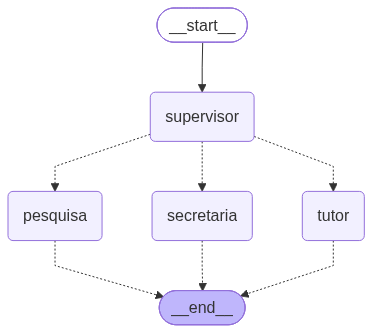

In [23]:
builder = StateGraph(EstadoMultiagente)

builder.add_node("supervisor", supervisor)
builder.add_node("tutor", no_tutor)
builder.add_node("secretaria", no_secretaria)
builder.add_node("pesquisa", no_pesquisa)

builder.add_edge(START, "supervisor")

grafo_multiagente = builder.compile()
display_graph(grafo_multiagente)


Testando com a mesma pergunta ambígua de novo:

In [27]:
resultado = grafo_multiagente.invoke(
    {"messages": [{"role": "user", "content": pergunta_ambigua}]}
)
print_last_message(resultado)
print()
print("Nó que respondeu:", resultado["messages"][-1])


Não posso confirmar o conteúdo específico do seu certificado. No entanto, posso ajudar com informações sobre o que é um checkpointer ou sobre os módulos do curso LangGraph. Se precisar de detalhes sobre o curso, por favor, me avise!


Nó que respondeu: content='Não posso confirmar o conteúdo específico do seu certificado. No entanto, posso ajudar com informações sobre o que é um checkpointer ou sobre os módulos do curso LangGraph. Se precisar de detalhes sobre o curso, por favor, me avise!' additional_kwargs={'refusal': None} response_metadata={'token_usage': {'completion_tokens': 49, 'prompt_tokens': 102, 'total_tokens': 151, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cache_write_tokens': None, 'cached_tokens': 0}}, 'model_provider': 'openai', 'model_name': 'gpt-4o-mini-2024-07-18', 'system_fingerprint': 'fp_ab203f6842', 'id': 'chatcmpl-ECVYF2ihEoC7wvGUSdOdNXxYxJdTG', 'service_tier': 'default', 'finish_reason': 'stop', 'logprobs': None} id='lc_run--019ffca4-b612-7d51-96a3-0a6037817ebd-0' tool_calls=[] invalid_tool_calls=[] usage_metadata={'input_tokens': 102, 'output_tokens'

## Discussão

Agora o grafo mostrado por `display_graph` tem **quatro nós visíveis** (`supervisor`, `tutor`, `secretaria`, `pesquisa`), em vez de um único agente com ferramentas opacas. Isso traz vantagens concretas sobre o orquestrador da seção 5:

- dá pra usar `checkpointer` e `store` diretamente neste grafo, porque ele é um `StateGraph` normal;
- dá pra inspecionar, com `get_state_history`, exatamente por qual especialista a execução passou;
- dá pra adicionar lógica **entre** os nós (ex.: sempre voltar ao supervisor depois de um especialista, em vez de encerrar direto) — algo que fica escondido dentro do agente orquestrador da seção 5.

O custo é escrever mais código explicitamente: aqui, nós escrevemos o `supervisor`, cada nó especialista e a montagem do grafo à mão, em vez de deixar o `create_agent` do orquestrador cuidar disso.

Repare também que, nesta versão, cada especialista sempre volta direto para `END` (`Command(goto="__end__", ...)`). Isso é uma escolha de design, não uma imposição do `Command`: se quiséssemos permitir que um especialista devolvesse o controle ao supervisor (por exemplo, para o supervisor decidir se falta consultar outro especialista), bastaria trocar `"__end__"` por `"supervisor"` no `goto` de cada nó — voltando ao supervisor até ele decidir que a resposta está completa.


---

# 7. Comparando as arquiteturas

| | Roteamento manual (seção 3) | Orquestrador — *subagents as tools* (seção 5) | Arquitetura de grafo (seção 6) |
|---|---|---|---|
| Quem decide o próximo agente | regra fixa em Python | LLM, dentro do orquestrador | LLM, em um nó supervisor explícito |
| Visibilidade da decisão | total (é só um `if`) | nenhuma (dentro da ferramenta) | total (nó dedicado, inspecionável) |
| Consegue consultar mais de um especialista? | não | sim, naturalmente | sim, com mais código |
| Integra com checkpointer/store direto | não se aplica | sim (é um `create_agent`, que é um grafo) | sim |
| Esforço de implementação | mínimo | baixo | médio |
| Quando escolher | poucos agentes, escopos muito distintos | maioria dos casos — comece por aqui | quando precisar de controle fino sobre o fluxo, auditoria, ou lógica entre os agentes |

Na prática, a recomendação mais recente do próprio LangChain é começar pelo padrão de **subagents as tools** (seção 5) para a maioria dos casos, e só migrar para uma arquitetura de grafo explícita (seção 6) quando o time-a-time real exigir mais controle do que uma ferramenta consegue expressar.


---

# 8. Exercícios de fixação

## Exercício 1 — Um quarto especialista

Crie um `agente_boas_vindas`, com um prompt focado em receber alunos novos e explicar como o curso funciona (sem ferramentas). Adicione-o ao orquestrador da seção 5 como uma nova *tool* `falar_com_boas_vindas`.

## Exercício 2 — Quebrando o roteamento trivial

Escreva três perguntas que **não deveriam** funcionar bem com o `rotear_pergunta` da seção 3 (mas que o orquestrador da seção 5 resolveria melhor). Rode as três em ambos e compare as respostas.

## Exercício 3 — Voltando ao supervisor

Modifique os nós especialistas da seção 6 para que, em vez de `Command(goto="__end__", ...)`, eles voltem para `Command(goto="supervisor", ...)`. Modifique o `supervisor` para decidir, além do próximo especialista, quando a resposta já está completa (adicione a opção `"fim"` ao `Literal` de `DecisaoRoteamento`).

## Exercício 4 — Checkpointer no grafo multiagente

Compile `grafo_multiagente` com um `checkpointer` (Notebook 5) e rode duas perguntas na mesma `thread_id`. Confirme que o histórico de mensagens é mantido entre as chamadas, mesmo passando por especialistas diferentes.

## Exercício 5 — Discussão

Sem escrever código: em que situação você usaria a arquitetura de grafo (seção 6) mesmo tendo só dois agentes especialistas? Dê um exemplo concreto de lógica que só faz sentido com um nó supervisor explícito, e que um orquestrador do tipo *subagents as tools* não conseguiria expressar facilmente.

---

# 9. Resumo da aula

Neste notebook, evoluímos de um agente único para uma pequena equipe de agentes especialistas. Os pontos principais foram:

- um agente generalista cresce mal: prompt inchado, ferramentas demais, difícil de testar;
- com poucos agentes de escopo bem distinto, um roteamento trivial em Python já resolve;
- roteamento por palavra-chave não escala: não entende intenção e quebra com perguntas ambíguas ou mais agentes;
- o padrão **subagents as tools** transforma cada agente especialista em uma ferramenta de um agente orquestrador — é a recomendação atual do LangChain para a maioria dos casos;
- a **arquitetura de grafo**, com `StateGraph` e `Command`, torna o fluxo entre agentes explícito e inspecionável, ao custo de mais código;
- a escolha entre as duas não é definitiva: dá para começar pelo orquestrador e migrar para grafo quando o controle fino for necessário.


## 9.1 Checklist de compreensão

Antes de seguir, você deve conseguir responder:

1. Por que um único agente generalista tende a piorar conforme o escopo cresce?
2. Em que situação um roteamento por palavra-chave (`if/else`) ainda é uma escolha razoável?
3. O que é o padrão *subagents as tools*, e por que o grafo de um orquestrador parece igual ao de um agente comum com ferramentas?
4. O que o `Command(goto=...)` faz, e por que ele dispensa `add_edge` entre supervisor e especialistas?
5. Cite uma vantagem prática da arquitetura de grafo sobre o orquestrador por ferramentas.


## 9.2 Próximos passos

A partir daqui, os próximos passos naturais são:

- combinar a arquitetura de grafo com memória de curto e longo prazo (Notebooks 5 e 6), dando a cada especialista acesso ao mesmo `store`;
- explorar arquiteturas de **rede** (*network*), em que os próprios agentes especialistas decidem para qual outro agente passar o controle, sem um supervisor central;
- adicionar aprovação humana (*human-in-the-loop*) antes de ações sensíveis executadas por um especialista, como a emissão de uma declaração.


# 10. Referências

- LangChain — Agents (`create_agent`): https://docs.langchain.com/oss/python/langchain/agents
- LangChain — Multi-agent (subagents as tools): https://docs.langchain.com/oss/python/langchain/multi-agent/subagents-personal-assistant
- LangGraph — Multi-agent concepts: https://docs.langchain.com/oss/python/langgraph/multi-agent
- LangGraph — `Command`: https://reference.langchain.com/python/langgraph/types/#langgraph.types.Command
